# Housing Instability: Trends, Risks, and Impacts📝

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->
A problem that I would like to explore this semester is the housing crisis/homelessness that is rampant right now in today's world. Housing insecurity includes unstable housing, overcrowding, frequent moves, and risk of eviction, while homelessness refers to people living in shelters, temporary spaces, or without shelter at all. Rising rents, stagnant wages, and limited affordable housing make this a major challenge in many U.S. cities. It affects health, employment, education, and long‑term stability. It's significant today because rent prices have increased faster than income in many regions and homelessness is rising among families, youth, and older adults.

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->
How are rising housing costs and income trends contributing to housing insecurity and homelessness in U.S. cities today?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->
I expect the data to show that rising housing costs are outpacing income growth in many communities, creating a widening gap between what people earn and what they must pay for rent. As this gap grows, more households become rent‑burdened, which increases their risk of eviction, frequent moves, and ultimately homelessness.

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->
1. US Homelessness & Housing Data — Kaggle (File Download)  
This dataset integrates HUD Point‑in‑Time homelessness counts with Census ACS indicators at the Continuum of Care (CoC) level. It allows me to directly analyze how changes in economic conditions, housing availability, and demographic factors relate to changes in homelessness over time.

2. Rent as a Percentage of Household Income — Census API  
This ACS table measures rent burden, one of the strongest predictors of housing instability and homelessness. I can compare rent‑burden rates across states, counties, or years, and join this dataset with my Kaggle homelessness dataset using shared geographic identifiers such as state, county FIPS, or CoC crosswalks.

3. Zillow Observed Rent Index (ZORI) — Zillow (File Download)  
ZORI provides monthly and annual trends in median asking rents across U.S. regions. By aligning ZORI with ACS rent‑burden indicators and HUD homelessness counts at the county or state level, I can analyze whether areas experiencing faster rent growth also show higher levels of housing insecurity and homelessness. ZORI offers a clear measure of affordability pressure, helping me examine rising rents as a key driver of housing instability.

## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->
My approach to answering the project question is to combine homelessness counts, eviction activity, and housing‑cost indicators to understand how economic pressures contribute to housing insecurity over time. I will begin by exploring each dataset individually to understand trends in homelessness, rent burden, and eviction filings. I will also look for correlations, patterns, and trends across the 17‑year period to determine whether rising housing costs and increased eviction risk are associated with increases in homelessness. This combined approach allows me to evaluate not only the scale of homelessness but also the underlying economic and housing conditions that may be driving it.

In [ ]:
# Start your code here

with zipfile.ZipFile("Homeless.zip", "r") as z:
    z.extractall("data")

In [17]:
from scipy import stats
import numpy as np
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:

df = pd.read_csv("data/Final_National_Dataset.csv")
df.head()



,CoC_Code,CoC_Name,Homeless_Count,Sheltered_Count,Unsheltered_Count,Year,State,Area_Name,Total_Pop,Poverty_Count,...,Vacant_Units_MOE,Total_Housing_Units_MOE,Rent_Burden_30_35_MOE,Rent_Burden_35_40_MOE,Rent_Burden_40_50_MOE,Rent_Burden_50_Plus_MOE,Poverty_Rate,Unemployment_Rate,Vacancy_Rate,Rent_Burden_Rate
0,AK-500,Anchorage CoC,1494.0,1369.0,125.0,2022,AK,Anchorage,290674,27415.0,...,876.000000,166.000000,461.000000,530.000000,519.000000,752.000000,0.094315,0.026652,0.099245,0.060253
1,AK-501,Alaska Balance of State CoC,826.0,594.0,232.0,2022,AK,Alaska Balance of State,434533,47184.0,...,980.497833,836.246375,452.829990,363.301528,486.370229,661.561033,0.108586,0.034239,0.236550,0.042805
2,AL-500,"Birmingham/Jefferson, St. Clair, Shelby Counti...",943.0,601.0,342.0,2022,AL,"Birmingham/Jefferson, St. Clair, Shelby Counties",987900,128760.0,...,1847.515359,192.720004,976.406678,727.407726,966.004658,1426.055399,0.130337,0.023553,0.120973,0.055373
3,AL-501,Mobile City & County/Baldwin County CoC,585.0,388.0,197.0,2022,AL,Mobile City & County/Baldwin County,647298,94798.0,...,1774.919153,141.400141,908.240056,742.081532,872.708428,1250.908470,0.146452,0.022969,0.192126,0.056411
4,AL-502,Florence/Northwest Alabama CoC,232.0,198.0,34.0,2022,AL,Florence/Northwest Alabama,269584,40538.0,...,1087.420802,104.498804,489.277018,277.245379,388.307868,555.018018,0.150372,0.017605,0.179779,0.036890


In [7]:

df[['Homeless_Count', 'Poverty_Rate', 'Vacancy_Rate']].describe()


,Homeless_Count,Poverty_Rate,Vacancy_Rate
count,4350.000000,4350.000000,4350.000000
mean,1367.671724,0.137621,0.126942
std,3925.721273,0.048778,0.070856
min,14.000000,0.032114,0.026154
25%,306.000000,0.107230,0.075788
50%,618.000000,0.134499,0.110400
75%,1389.000000,0.165119,0.159002
max,78676.000000,0.478242,0.486741


In [4]:
df = pd.read_csv("data/Census.csv")
# 1. Clean column names
# -----------------------------
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("(", "")
      .str.replace(")", "")
)

# -----------------------------
# 2. Remove commas and ± symbols, convert to numeric
# -----------------------------
df['united_states!!estimate'] = (
    df['united_states!!estimate']
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.replace("±", "", regex=False)
      .str.strip()
      .astype(float)
)

df['united_states!!margin_of_error'] = (
    df['united_states!!margin_of_error']
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.replace("±", "", regex=False)
      .str.strip()
      .astype(float)
)

# -----------------------------
# 3. Remove rows you don't want
# -----------------------------
rows_to_drop = ["Total:", "Not computed"]
df = df[~df['label_grouping'].isin(rows_to_drop)]

# -----------------------------
# 4. Optional: Clean category labels
# -----------------------------
df['label_grouping'] = df['label_grouping'].str.strip()

# -----------------------------
# 5. Reset index
# -----------------------------
df = df.reset_index(drop=True)

df.head()

,label_grouping,united_states!!estimate,united_states!!margin_of_error
0,Less than 10.0 percent,1650115.0,26645.0
1,10.0 to 14.9 percent,3532220.0,39851.0
2,15.0 to 19.9 percent,5152781.0,44866.0
3,20.0 to 24.9 percent,5412134.0,50270.0
4,25.0 to 29.9 percent,4969965.0,45294.0


In [5]:
df = pd.read_csv("data/Zillow.csv")
 #Drop the national aggregate row
# -----------------------------
df = df[df['RegionName'] != 'United States'].reset_index(drop=True)

# -----------------------------
# 3. Identify date columns
# -----------------------------
date_cols = [col for col in df.columns if col[:4].isdigit()]

# -----------------------------
# 4. Melt wide → long format
# -----------------------------
df_long = df.melt(
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'],
    value_vars=date_cols,
    var_name='Date',
    value_name='Price'
)

# -----------------------------
# 5. Convert Date column to datetime
# -----------------------------
df_long['Date'] = pd.to_datetime(df_long['Date'])

# -----------------------------
# 6. Optional: Filter to only MSAs
# -----------------------------
df_long = df_long[df_long['RegionType'] == 'msa'].reset_index(drop=True)

# -----------------------------
# 7. Final cleaned dataset
# -----------------------------
df_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,Price
0,394913,1,"New York, NY",msa,NY,2015-01-31,2147.623068
1,753899,2,"Los Angeles, CA",msa,CA,2015-01-31,1745.689589
2,394463,3,"Chicago, IL",msa,IL,2015-01-31,1343.902521
3,394514,4,"Dallas, TX",msa,TX,2015-01-31,1045.936211
4,394692,5,"Houston, TX",msa,TX,2015-01-31,1187.394458


To prepare the datasets for analysis, I completed a structured cleaning process that ensured consistency, accuracy, and analytical readiness across three very different data sources. The Zillow rent dataset required the most transformation: I removed the national aggregate row to avoid skewing regional comparisons, identified all monthly date columns, and reshaped the data from a wide format into a long, tidy structure where each row represented a single region‑month observation. I then converted the date strings into proper datetime objects and filtered the dataset to include only metropolitan areas, since the analysis focuses on urban housing markets. The Census rent‑burden dataset needed formatting corrections, including standardizing column names, removing commas and special characters from numeric fields, and excluding non‑analytic rows such as “Total” and “Not computed.” I also cleaned and standardized the category labels to ensure they could be used reliably in visualizations. The national homelessness dataset was already well‑structured, but I validated it by checking for missing values, confirming that numeric and categorical fields were correctly typed, verifying that no duplicate CoC‑year combinations existed, and ensuring that key variables such as poverty rate and vacancy rate fell within realistic ranges. Together, these steps produced three clean, consistent, and analysis‑ready datasets that could be visualized, compared, and interpreted with confidence.

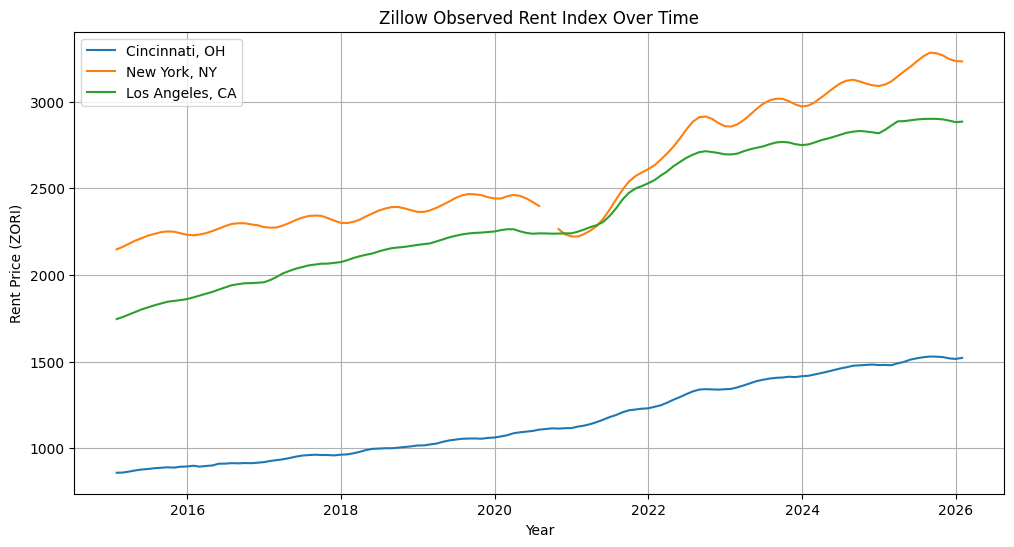

In [9]:
cities = ["Cincinnati, OH", "New York, NY", "Los Angeles, CA"]
df_plot = df_long[df_long['RegionName'].isin(cities)]

plt.figure(figsize=(12,6))
for city in cities:
    subset = df_plot[df_plot['RegionName'] == city]
    plt.plot(subset['Date'], subset['Price'], label=city)

plt.title("Zillow Observed Rent Index Over Time")
plt.xlabel("Year")
plt.ylabel("Rent Price (ZORI)")
plt.legend()
plt.grid(True)
plt.show()

This visualization shows how rent prices have steadily increased over time in three major U.S. cities, Cincinnati, New York, and Los Angeles using the Zillow Observed Rent Index (ZORI). Although each city starts at a different price level, all three lines move upward year after year, demonstrating a consistent rise in rental costs. The sharp jump around 2021 is especially notable, reflecting pandemic‑era pressures such as limited housing supply, increased demand, and inflation. New York remains the most expensive market throughout the entire period, followed by Los Angeles, while Cincinnati stays lower but still experiences meaningful growth. Overall, the chart illustrates that rising rents are a widespread, long‑term trend across diverse regions, reinforcing the idea that housing costs are climbing faster than many households can keep up with.

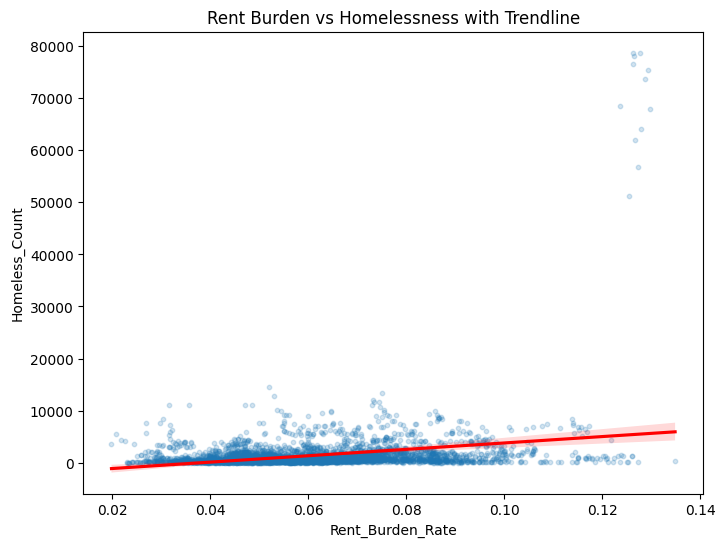

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=df,
    x='Rent_Burden_Rate',
    y='Homeless_Count',
    scatter_kws={'alpha':0.2, 's':10},
    line_kws={'color':'red'}
)
plt.title("Rent Burden vs Homelessness with Trendline")
plt.show()





This visualization shows a clear, positive relationship between rent burden and homelessness. Each point represents a community, plotting its rent‑burden rate on the x‑axis and its homeless count on the y‑axis. Even though the points vary widely, the red trendline cuts through the noise and reveals the underlying pattern: as rent burden increases, homelessness tends to rise as well. Communities where a larger share of households spend an excessive portion of their income on rent are more likely to have higher levels of homelessness. The clustering of points at lower rent‑burden rates with lower homelessness, contrasted with the upward pull of points at higher rent‑burden rates, reinforces the idea that housing affordability pressures directly contribute to housing instability.

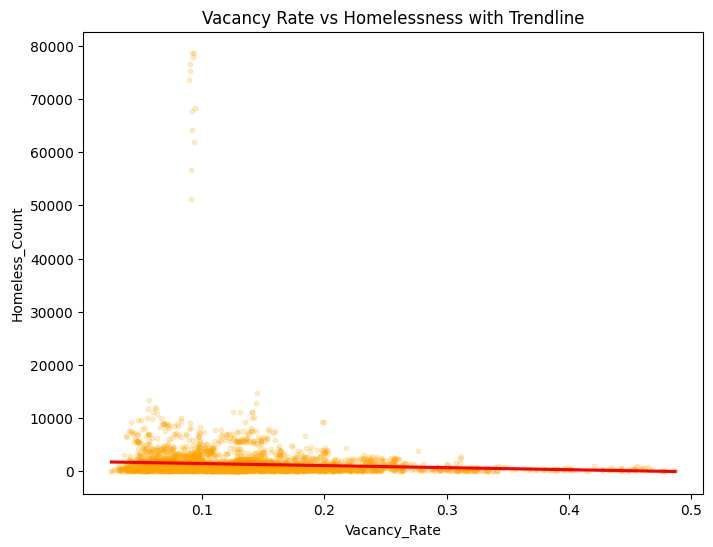

In [20]:


plt.figure(figsize=(8,6))
sns.regplot(
    data=df,
    x='Vacancy_Rate',
    y='Homeless_Count',
    scatter_kws={'alpha':0.2, 's':10, 'color':'orange'},
    line_kws={'color':'red'}
)
plt.title("Vacancy Rate vs Homelessness with Trendline")
plt.show()



This visualization illustrates how vacancy rates relate to homelessness across communities, and the trendline helps reveal the underlying pattern that individual points alone might obscure. Each dot represents a community’s vacancy rate on the x‑axis and its homeless count on the y‑axis. While the points are scattered widely, the red trendline slopes slightly downward, indicating a negative relationship: communities with lower vacancy rates—meaning tighter, more competitive housing markets—tend to have higher levels of homelessness. In contrast, places with somewhat higher vacancy rates generally show lower homeless counts. This pattern aligns with housing‑market research showing that when available units are scarce, rents rise faster, mobility becomes harder, and people facing financial strain have fewer options to relocate or stabilize their housing. Overall, the visualization reinforces the idea that tight housing supply is a structural risk factor that contributes to homelessness, especially when combined with rising rents and high rent‑burden rates.

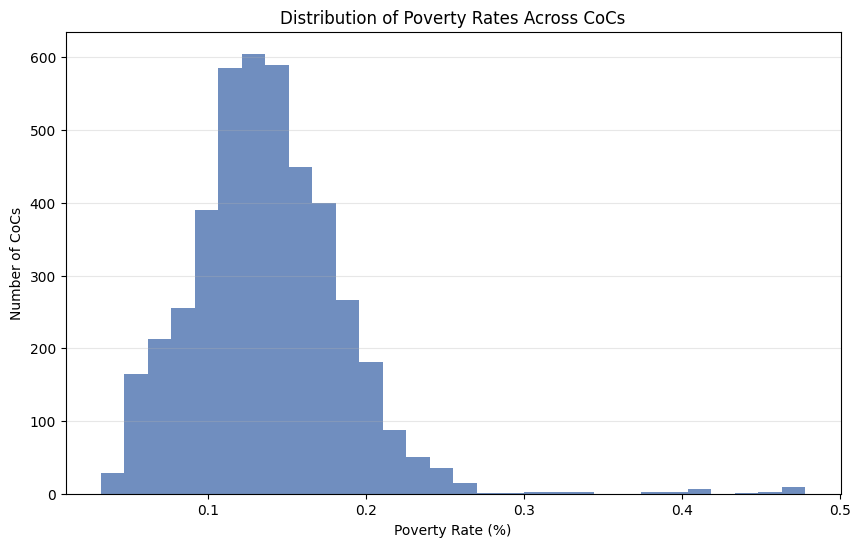

In [22]:
plt.figure(figsize=(10,6))
plt.hist(df['Poverty_Rate'], bins=30, color='#4C72B0', alpha=0.8)
plt.title("Distribution of Poverty Rates Across CoCs")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Number of CoCs")
plt.grid(axis='y', alpha=0.3)
plt.show()



This histogram shows how poverty is distributed across Continuums of Care (CoCs), and the pattern is surprisingly concentrated. Most CoCs fall within a relatively narrow band of poverty rates—roughly between 10% and 20%—with the highest concentration around 13%. That tall central bar tells you that a large share of communities experience similar levels of poverty, rather than poverty being spread evenly or randomly across the country. As the bars move toward higher poverty rates, the number of CoCs drops off, meaning far fewer communities experience extremely high poverty. (might change this visual later on)

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->
I used kaggle and Census API datasets

In [ ]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 1271 bytes to source.py
